In [28]:
#Can Indian states be grouped into distinct development categories based on SDG indicators?

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [30]:
master = pd.read_csv("../output/SDG_Master.csv")

print(master.shape)

master.head()

(36, 134)


,state,year,sdg_india_index_no_poverty,sdg_india_index_zero_hunger,sdg_india_index_good_health_and_well_being,sdg_india_index_quality_education,sdg_india_index_gender_equality,sdg_india_index_clean_water_and_sanitation,sdg_india_index_affordable_and_clean_energy,sdg_india_index_decent_work_and_economic_growth,...,functioning_branches_of_commercial_banks_per_1_00_000_population,automated_teller_machines_atms_per_1_00_000_population,women_account_holders_under_pradhan_mantri_jan_dhan_yojana_pmjdy_percent,targeted_habitations_connected_by_all_weather_roads_under_pradhan_mantri_gram_sadak_yojana_pmgsy,share_of_gross_value_added_gva_in_manufacturing_to_total_gross_value_added_gva_in_current_prices_percent,manufacturing_employment_as_a_percentage_of_total_employment_percent,innovation_score_as_per_the_india_innovation_index,score_as_per_logistics_ease_across_different_states_leads_report,mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications,internet_subscribers_per_100_population_as_per_deptof_telecommunications
0,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2020",71,45,68,57,68,87,100,59,...,18.796992,29.824561,47.94,0.000000,1.089261,7.19,18.89,NaN,87.87,NaN
1,Andhra Pradesh,"Calendar Year (Jan - Dec), 2020",81,52,77,50,58,92,100,67,...,14.397612,21.008004,59.31,98.460292,9.580831,10.60,24.19,3.42,85.71,65.61
2,Arunachal Pradesh,"Calendar Year (Jan - Dec), 2020",54,66,64,41,37,67,85,50,...,11.826544,16.360053,55.05,81.747270,3.200942,2.05,14.90,2.77,84.00,52.34
3,Assam,"Calendar Year (Jan - Dec), 2020",51,41,59,43,25,64,98,50,...,8.892593,11.600034,59.26,94.376955,12.252417,10.55,16.38,3.00,67.51,41.57
4,Bihar,"Calendar Year (Jan - Dec), 2020",32,31,66,29,48,91,78,50,...,6.372698,6.841954,56.22,97.182163,7.213315,5.30,14.48,2.85,50.65,30.99


In [31]:
sdg_cols = [
    col for col in master.columns
    if col.startswith("sdg_india_index")
]

X_cluster = master.drop(
    columns=
    sdg_cols +
    [
        "state",
        "year",
        "composite_score_of_sdg_india_index"
    ]
)

print(X_cluster.shape)

(36, 116)


In [32]:
drop_cols = [
    "mean_shore_zone_coastal_water_quality_total_nitrogen_tn",
    "mean_shore_zone_coastal_water_quality_biochemical_oxygen_demand_bod",
    "increase_in_area_under_mangroves_percent",
    "average_marine_acidity_ph_measured_at_representative_sampling_stations_in_the_shore_zone",
    "potential_area_available_for_developed_under_aquaculture_percent"
]

X_cluster = X_cluster.drop(
    columns=drop_cols
)

In [33]:
X_cluster = X_cluster.fillna(
    X_cluster.median(numeric_only=True)
)

In [34]:
X_cluster.isnull().sum().sum()

np.int64(0)

In [35]:
scaler = StandardScaler() # standardize data to have mean=0 and variance=1

X_scaled = scaler.fit_transform(
    X_cluster
)

In [36]:
X_scaled.shape

(36, 111)

In [37]:
X_scaled

array([[-1.57863903, -0.92864269, -1.05624487, ..., -0.13179843,
        -0.29754752, -0.26572764],
       [-0.81636201, -0.2879314 ,  2.28632949, ...,  0.45542229,
        -0.36435653,  0.22687387],
       [ 1.55134476,  0.36014439,  1.49556081, ..., -0.56242696,
        -0.41724699, -0.26572764],
       ...,
       [ 1.06423116,  1.56792199, -1.03683951, ..., -0.07699116,
        -0.92388196, -0.77095045],
       [-0.62486315, -0.16273494, -0.38675973, ..., -0.4371532 ,
         0.49766524, -0.77095045],
       [ 0.18575338,  0.50006984,  0.28757675, ..., -0.21792413,
        -0.51034658, -0.28800051]], shape=(36, 111))

In [38]:
inertia = [] # now we find optimal number of clusters using elbow method

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(  # inertia is the sum of squared distances of samples to their closest cluster center
        kmeans.inertia_
    )

In [39]:
inertia

[3402.870830375501,
 3000.639850200556,
 2784.4277316158036,
 2680.5247382969783,
 2399.8801687336677,
 2251.313581920371,
 2120.3069938512995,
 1966.6581598861399,
 1844.4247889877934]

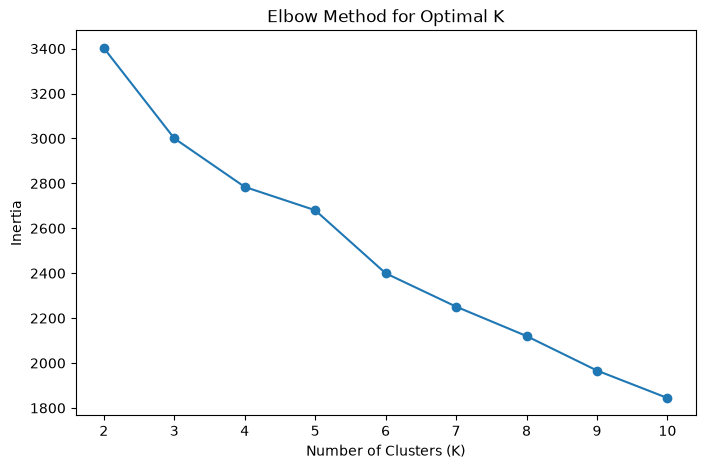

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Optimal K"
)

plt.show()

# From graph, we can see that the optimal number of clusters is 4. Let's fit the KMeans model with 4 clusters and assign cluster labels to each state.

In [41]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [42]:
master["cluster"] = clusters

C:\Users\trigu\AppData\Local\Temp\ipykernel_10852\2529146697.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master["cluster"] = clusters


In [43]:
master["cluster"].value_counts()

cluster
1    20
0    10
2     5
3     1
Name: count, dtype: int64

In [44]:
for cluster in sorted(master["cluster"].unique()):
    
    print(f"\nCluster {cluster}")
    
    print(
        master[
            master["cluster"] == cluster
        ]["state"].tolist()
    )


Cluster 0
['Assam', 'Bihar', 'Chhattisgarh', 'Jharkhand', 'Madhya Pradesh', 'Odisha', 'Rajasthan', 'Tripura', 'Uttar Pradesh', 'West Bengal']

Cluster 1
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Chandigarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Karnataka', 'Kerala', 'Ladakh', 'Maharashtra', 'Puducherry', 'Punjab', 'Sikkim', 'Tamil Nadu', 'Telangana', 'The Dadra And Nagar Haveli And Daman And Diu', 'Uttarakhand']

Cluster 2
['Arunachal Pradesh', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland']

Cluster 3
['Lakshadweep']


In [45]:
cluster_summary = master.groupby("cluster")[
    "composite_score_of_sdg_india_index"
].agg(["count","mean"])

cluster_summary

,count,mean
cluster,,
0,10,59.60
1,20,70.05
2,5,62.60
3,1,68.00


In [46]:
cluster_profile = master.groupby("cluster")[
    [
        "composite_score_of_sdg_india_index"
    ]
].mean()

cluster_profile

,composite_score_of_sdg_india_index
cluster,
0,59.60
1,70.05
2,62.60
3,68.00


In [47]:
#Create a Cluster Comparison Table
#Use the indicators that Random Forest said were important:

In [50]:
important_cols = [
    "population_in_the_lowest_two_wealth_quintiles_percent",
    "head_count_ratio_as_per_the_multidimensional_poverty_index_percent",
    "mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications",
    "functioning_branches_of_commercial_banks_per_1_00_000_population",
    "schools_with_access_to_basic_infrastructure_such_as_electricity_drinking_water_percent",
    "gross_enrolment_ratio_ger_in_higher_secondary_for_classes_11_to_12",
    "maternal_mortality_ratio_per_1_00_000_live_births",
    "composite_score_of_sdg_india_index"
]

master.groupby("cluster")[important_cols].mean().round(2)

,population_in_the_lowest_two_wealth_quintiles_percent,head_count_ratio_as_per_the_multidimensional_poverty_index_percent,mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications,functioning_branches_of_commercial_banks_per_1_00_000_population,schools_with_access_to_basic_infrastructure_such_as_electricity_drinking_water_percent,gross_enrolment_ratio_ger_in_higher_secondary_for_classes_11_to_12,maternal_mortality_ratio_per_1_00_000_live_births,composite_score_of_sdg_india_index
cluster,,,,,,,,
0,58.82,36.84,69.04,9.74,78.15,45.09,152.89,59.60
1,16.42,11.02,114.19,20.30,95.20,61.02,76.30,70.05
2,38.30,22.34,82.24,11.43,59.05,44.15,NaN,62.60
3,1.20,1.80,124.28,20.59,100.00,73.50,NaN,68.00


In [52]:
# Top 10 Random Forest features.
top_features = [
    "population_in_the_lowest_two_wealth_quintiles_percent",
    "head_count_ratio_as_per_the_multidimensional_poverty_index_percent",
    "automated_teller_machines_atms_per_1_00_000_population",
    "mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications",
    "functioning_branches_of_commercial_banks_per_1_00_000_population",
    "schools_with_access_to_basic_infrastructure_such_as_electricity_drinking_water_percent",
    "gross_enrolment_ratio_ger_in_higher_secondary_for_classes_11_to_12",
    "industries_complying_with_wastewater_treatment_17_categories_of_highly_polluting_industries_or_grossly_polluting_or_red_category_of_industries_complying_with_wastewater_treatment_percent",
    "population_living_below_the_national_poverty_line_percent",
    "maternal_mortality_ratio_per_1_00_000_live_births"
]

In [53]:
cluster_profile = (
    master.groupby("cluster")[top_features]
    .mean()
    .round(2)
)

cluster_profile

,population_in_the_lowest_two_wealth_quintiles_percent,head_count_ratio_as_per_the_multidimensional_poverty_index_percent,automated_teller_machines_atms_per_1_00_000_population,mobile_connections_per_100_persons_mobile_tele_density_as_per_deptof_telecommunications,functioning_branches_of_commercial_banks_per_1_00_000_population,schools_with_access_to_basic_infrastructure_such_as_electricity_drinking_water_percent,gross_enrolment_ratio_ger_in_higher_secondary_for_classes_11_to_12,industries_complying_with_wastewater_treatment_17_categories_of_highly_polluting_industries_or_grossly_polluting_or_red_category_of_industries_complying_with_wastewater_treatment_percent,population_living_below_the_national_poverty_line_percent,maternal_mortality_ratio_per_1_00_000_live_births
cluster,,,,,,,,,,
0,58.82,36.84,11.98,69.04,9.74,78.15,45.09,86.65,28.50,152.89
1,16.42,11.02,32.06,114.19,20.30,95.20,61.02,87.92,11.69,76.30
2,38.30,22.34,13.82,82.24,11.43,59.05,44.15,93.48,24.54,NaN
3,1.20,1.80,97.06,124.28,20.59,100.00,73.50,NaN,2.77,NaN


In [54]:
master.to_csv("../output/SDG_Master_Clustered.csv", index=False)